# ETFs: a neural network on the same flat table, and what an ensemble of them costs

[`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb) read the same design matrix: one row
per fund per decision date, one column per feature, no notion that the rows are ordered in time.
They differ in what they can represent. A penalized linear model gives each feature one
coefficient and can spread weight across a group of near-duplicate columns. A tree ensemble can
express an interaction - a condition on one feature evaluated inside a region defined by
others - but it reaches an interaction by choosing one column at each split, and the feature set
here is **collinear**: several columns carry almost the same information, so which one gets
chosen is close to arbitrary.

A neural network on the same table is a third answer to the same question. Its first layer is a
weighted sum of every feature, so like a linear model it never has to choose among correlated
columns; the nonlinearity after it means the sums can be combined into interactions the linear
model cannot write down. That is the reason to try one here rather than a general preference for
neural networks: the two properties that pulled against each other in the previous two notebooks
are not obviously in conflict in this architecture.

**TabM is an ensemble, and the ensemble is the point.** Averaging several independently
initialized networks is a standard way to make a neural fit on a small table less erratic, and
the cost is that you train several networks. TabM trains most of one. A two-layer network - the
backbone - is shared by every member. Each member then owns two small things of its own: a
vector carrying one number per hidden unit, which multiplies the backbone's output element by
element, and its own final linear layer turning that scaled output into a prediction. The
members' predictions are averaged. So what differs between members is one vector and one output
layer each, set against a backbone whose two layers are as wide as the hidden size - which is
why adding members grows the model far more slowly than training that many separate networks
would. The grid here varies two dials together: the width of the shared backbone and the number
of members.

**A neural fit has a meaningful state at every epoch**, in the way a boosted model has one at
every iteration and a linear fit does not. An **epoch** is one pass over the training rows. The
configurations here train for 200 of them and save the weights every 25, so each configuration
produces eight scoreable models rather than one, and each is registered separately. The count
that matters downstream is configurations times checkpoints, not configurations.

**Learning objectives.** By the end of this notebook you will be able to:

- Describe what a weight-sharing ensemble holds in common between its members and what it keeps
  separate, and say why that makes *k* members cost far less than *k* networks.
- Read the epoch schedule out of a declared configuration and say how many scoreable models the
  run will publish for it.
- Read a curve of out-of-sample ranking accuracy against training epoch, and tell apart a model
  still learning from one that has started fitting the training window.
- Say why comparing configurations at their own individual best epochs is a choice made after
  seeing the answer, and where in this case study that choice is legitimately made instead.
- Recognise when a model has predicted nearly the same value for every fund on a date, why that
  date then contributes nothing to the ranking measure, and how to keep such a configuration out
  of a comparison.

**Book reference**: Chapter 12, Section 12.3 (Deep Learning Alternatives). Chapter 6, Section 6.7
(Search accounting and run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb) fitted the two populations this one
sits beside.

**What it writes**: one training run per configuration and one complete validation prediction set
per configuration and epoch checkpoint, in `run_log/registry.db` and under `run_log/training/`
and `run_log/predictions/`, grouped under a named population.
[`13_model_analysis`](13_model_analysis.ipynb) compares that population against the other
families, and [`14_backtest`](14_backtest.ipynb) backtests every member and selects on validation
backtest Sharpe. **Selection happens there, not here.** The ranking below shows what capacity and
training length do to a ranking measure; it decides nothing.

In [1]:
"""Fit the declared ETF tabular neural-network population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""
DEVICE: str = ""

In [4]:
study = open_study("etfs", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which labels, and which models

The labels are the two the previous notebooks fitted: `fwd_ret_21d`, the total return over the 21
trading days after the decision date, and the five-day variant `fwd_ret_5d`. Each carries its own
training menu at `config/training/{label}.yaml`, and this notebook fits the union of them, so the
family covers the same horizons the linear and boosted families do and nothing downstream has to
work around a horizon that was never fitted. `LABELS` restricts the run to a subset when you want
one.

In [5]:
declared_labels(study, "tabular_dl")

('fwd_ret_21d', 'fwd_ret_5d')

The menu names three configurations, and each resolves to a preset in
`case_studies/config/tabm/`. `hidden_dim` is the width of the shared network - how many units
each of its layers has - and `n_members` is how many rescaled views of that network are averaged
together. The three step both dials at once, from 64 units and 4 members to 256 and 16, so the
grid asks whether a bigger and more heavily averaged model does better on a cross-section of
fewer than a hundred funds; it does not separate width from ensemble size. `dropout` is the
fraction of units switched off at random on each training pass, which stops the network leaning
on any one of them.

`n_epochs` and `checkpoint_interval` are declared alongside the architecture rather than passed
in here, because they decide how many prediction sets each configuration owes: 200 epochs saved
every 25 is eight, and a run that quietly trained for fewer would publish a different population
under the same name.

In [6]:
configs = load_model_configs(
    study,
    "tabular_dl",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
# Every row of this family is the same network, so the estimator column the linear and boosted
# menus vary is dropped here and the declared parameters carry the whole difference.
configs.select("label", "config_name", "params")

label,config_name,params
str,str,str
"""fwd_ret_21d""","""tabm_s""","""dropout=0.1, hidden_dim=64, n_…"
"""fwd_ret_21d""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…"
"""fwd_ret_21d""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…"
"""fwd_ret_5d""","""tabm_s""","""dropout=0.1, hidden_dim=64, n_…"
"""fwd_ret_5d""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…"
"""fwd_ret_5d""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name. Comparing the loaded rows against the complete
declared catalog catches either knob, and says so here rather than several cells later in a
message about hashes.

The device is checked in the same cell. A network trained on a GPU and the same network trained on
a CPU accumulate their sums in different orders and reach different weights, so the device is
part of what the fitted model is and is recorded inside the computation's identity rather than
beside it. `PUBLISHED_DEVICE` is the device this population was fitted on. The runner refuses to
substitute a CPU for a requested GPU rather than publishing a different model under the published
name, so on a machine with no NVIDIA card this notebook stops at the next cell; set
`DEVICE="cpu"` and pass a `POPULATION_NAME` to fit the same grid there.

In [7]:
PUBLISHED_DEVICE = "cuda"
device = DEVICE or PUBLISHED_DEVICE
print(f"training device: {device}")

if (
    narrows_declared_catalog(study, "tabular_dl", configs) or device != PUBLISHED_DEVICE
) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs on device {device!r}, "
        f"which is not the complete declared catalog on {PUBLISHED_DEVICE!r}, so it cannot "
        f"publish the canonical population; pass POPULATION_NAME to give it its own"
    )

training device: cuda


## 2. Binding the declarations to the data

A menu entry says which network to fit. It does not say which feature columns exist today, where
the walk-forward folds fall, or which fund-date pairs have both a feature row and a label.
**Resolving** a request goes and finds all of that: it reads the label and feature files,
computes the fold boundaries from the walk-forward parameters in `config/setup.yaml`, and works
out the exact set of rows each fit is expected to predict.

Resolving reads the inputs and fits nothing, so the plan can be inspected before any training
starts. Four things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row of a label.**
  They are the width of the design matrix, the number of ETFs, and the number of fund-date pairs
  to be predicted. A row that differs is a configuration being measured on a different sample
  from its neighbours, and its results are not comparable with theirs.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  `05_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study, and any of it visible in
  this window would mean it had been used to choose something.
- **`checkpoints` is 8**, the epoch schedule declared above. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes
into one and what follows from it.

In [8]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides={"device": device},
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,date,date
"""tabm_l""",71,99,188473,8,8,2015-12-28,2023-11-29
"""tabm_m""",71,99,188473,8,8,2015-12-28,2023-11-29
"""tabm_s""",71,99,188473,8,8,2015-12-28,2023-11-29
"""tabm_l""",71,99,190009,8,8,2015-12-28,2023-12-21
"""tabm_m""",71,99,190009,8,8,2015-12-28,2023-12-21
"""tabm_s""",71,99,190009,8,8,2015-12-28,2023-12-21


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on the training rows
   only and then applied to the validation rows, so nothing from the validation window reaches
   the fit. A network needs this where a tree does not: gradient descent on inputs whose scales
   differ by orders of magnitude takes steps that are far too large in one direction and far too
   small in another,
3. trains for the declared number of epochs, writing the weights to disk every 25,
4. predicts the fold's validation rows from each saved set of weights.

Step 4 is what makes one training run produce eight results. The fold predictions are
concatenated into one series per checkpoint covering the whole validation period, and each
becomes its own registered prediction set with its own identity. Preparing a fold - slicing the
window, imputing, standardizing - depends on the data and not on the network, so it is work
several configurations could share. They share it when the requests are handed to the runner
unresolved, because that path walks folds on the outside and configurations on the inside.
Resolved first, as they are here so that the plan above can be shown against the real data,
each configuration prepares its own folds. That costs seconds on a cross-section this size and
buys a plan that can be read before anything is fitted.

**What the call publishes is a population**: a named, immutable list of the prediction sets it is
going to produce. The list is computed from the resolved specifications before the first fit and
written down, and afterwards every member must exist and be complete. That is what makes the
downstream comparison well defined - `14_backtest` backtests this population, not whatever
predictions happen to be in the registry - and it is why a configuration that raises fails the
whole call rather than publishing a population one member short. Everything that finished stays
registered, and re-running trains only what is missing.

`SUPERSEDES_POPULATION` names the population hash this run replaces, and is empty because this is
the first generation to be published under this name. A population is the set of prediction
identities, so anything that moves a training identity - a changed epoch schedule as much as a
changed configuration menu - produces a different population under the same name, and the
registry refuses to write it without being told which snapshot it supersedes. That lineage is the
only record of which generation is which, and the hash is part of what a snapshot is hashed over,
so a later run that changed something must carry the value it replaced rather than an empty one.
A reduced-scale run passes it empty whatever the default is: a population produced under a
reduction is thrown away with the workspace it was written to, so it has no lineage to extend.

The default name is the contract with the notebooks downstream - `13_model_analysis` and
`14_backtest` resolve this population by name - rather than a label of convenience, which is why
a run that narrows the member set has to pass its own.

In [9]:
population_name = POPULATION_NAME or "etfs-tabular_dl-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=SUPERSEDES_POPULATION or None,
)

reused = sum(1 for item in execution.diagnostics if item.get("reused"))
print(
    f"{len(execution.runs)} configurations: {len(execution.runs) - reused} trained, {reused} read"
)
print(f"population {population.name}: {len(population.members)} prediction sets")

Preparing and releasing folds...


  Fold 0: train=227,817  val=22,174


      epoch  25/200: loss=0.001412, IC=-0.0363


      epoch  50/200: loss=0.001228, IC=-0.0325


      epoch  75/200: loss=0.001148, IC=-0.0218


...

      epoch 200/200: loss=0.000194, IC=-0.0162


    Fold 7: best_ep=25, IC=+0.0194 (86.5s)


    → best_epoch=50, IC=-0.0013 (786.6s)



  Best: 3b127c96c165 @ epoch 50 (IC=-0.0013)


6 configurations: 6 trained, 0 read
population etfs-tabular_dl-validation-v1: 48 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the registry
already holds the matching rows and the saved weights, and the runner returns the stored result
rather than training again - so re-running this notebook unchanged costs the time it takes to
read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("etfs", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "tabular_dl", labels=["fwd_ret_21d"], config_names=["tabm_s", "tabm_xl"]
)
requests = model_requests(study, configs, overrides={"device": "cuda"})
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-tabm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not declare
raises rather than quietly fitting fewer models than you asked for. To fit something new, add a
preset at `case_studies/config/tabm/tabm_xl.yaml` and list `tabm_xl` under `tabular_dl:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one instead of replacing it - and that includes `n_epochs`
and `checkpoint_interval`, which decide how many members the population has.

Give the run its own `population_name`: a name refers to one set of members permanently, and
reusing it for a different set raises. Everything downstream reads the registry rather than the
notebook, so predictions produced this way are selected and backtested on the same footing as the
ones shipped here, inside your workspace.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What came out

One row per configuration and epoch checkpoint, read back from the registry. `ic_mean` is the
**information coefficient**: on each validation date, rank the funds by the model's prediction,
rank them by the return they went on to earn, correlate the two rankings, and average that daily
correlation over the validation period. It measures whether the model orders the cross-section
correctly, on a scale where zero is no relationship.

`ic_n_days` is how many validation dates produced a defined correlation, and it decides which
rows below are comparable with each other. A network that has settled into predicting nearly the
same value for every fund on a date gives that date no spread to rank, a constant has no rank
correlation with anything, and the date drops out of the average. Such a configuration's
`ic_mean` is then an average over the dates where it happened to stay non-degenerate, which is a
different sample from its neighbours'. `full_coverage` marks the rows measured on every date
their own label offers, and everything charted below is restricted to those.

**Coverage is judged within a label, not across them.** A 21-day label runs out of forward window
earlier than a five-day label does, so it has fewer scoreable dates before any model is fitted,
and one global maximum would mark the whole 21-day grid incomplete for a reason that has nothing
to do with the models.

In [10]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "complete",
        "checkpoint_value",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort(["label", "ic_mean"], descending=[False, True])
    .join(
        configs.select("config_name", "label", "params"),
        on=["config_name", "label"],
        how="left",
    )
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("tabular_dl execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels by
# whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
order_label = panel_labels[0]
print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "params",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(12)

48 candidate models: 3 configurations
at 8 checkpoints each, on 2 labels


label,config_name,params,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,str,str,i64,f64,f64,f64,bool
"""fwd_ret_21d""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…",75,0.04485,0.061556,1995.0,true
"""fwd_ret_21d""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…",100,0.040743,0.065579,1995.0,true
"""fwd_ret_21d""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…",50,0.039699,0.06207,1995.0,true
"""fwd_ret_21d""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…",125,0.038849,0.059996,1995.0,true
"""fwd_ret_21d""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…",200,0.038702,0.060653,1995.0,true
…,…,…,…,…,…,…,…
"""fwd_ret_21d""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…",25,0.027758,0.070135,1995.0,true
"""fwd_ret_21d""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…",100,0.026469,0.045103,1995.0,true
"""fwd_ret_21d""","""tabm_s""","""dropout=0.1, hidden_dim=64, n_…",50,0.026345,0.046983,1995.0,true


### What more training does

Each line traces one configuration's out-of-sample IC as epochs are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the network was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
around zero without trend never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. Both produce a respectable-looking maximum, which is why
the maximum is not what a configuration is judged on.

One panel per label, each with its own vertical scale, because a horizon that has something to
learn and one that does not would be averaged into a single indistinct band if they shared axes.

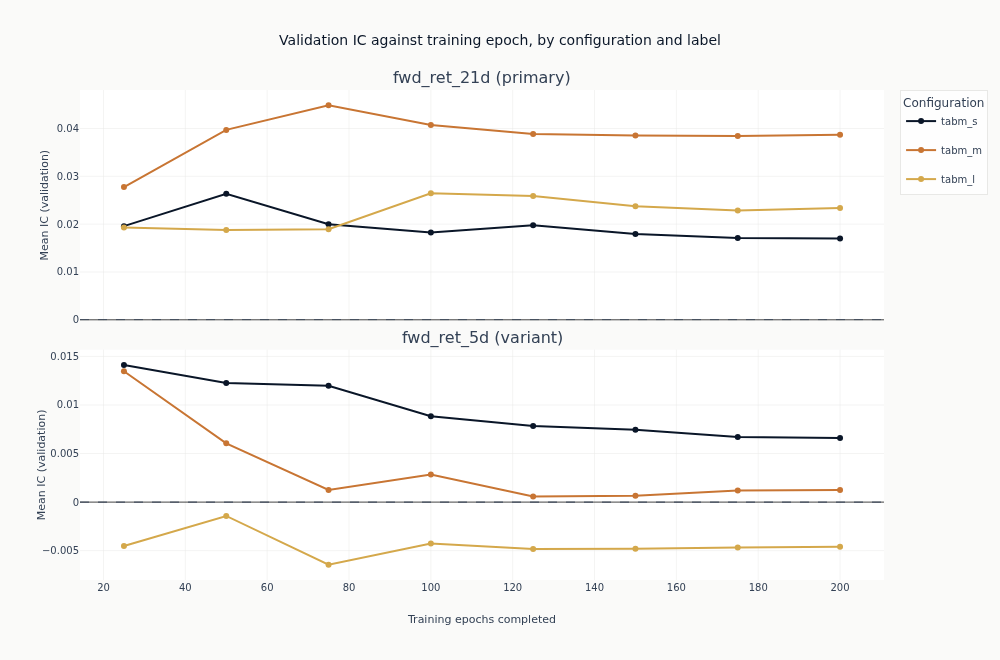

In [11]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
charted = set(curves.get_column("config_name"))
# Menu order, which is the order the frame in section 1 showed and the order the presets step
# capacity in. Sorting on the formatted parameter string instead would order 128 before 64.
config_order = [
    name
    for name in configs.get_column("config_name").unique(maintain_order=True)
    if name in charted
]
# One colour per configuration, so the same configuration keeps its colour in both figures. Three
# configurations against three distinct line colours; a fourth would need a fourth colour rather
# than a wrapped palette that gives two configurations the same swatch.
line_colors = [COLORS["blue"], COLORS["copper"], COLORS["amber"], COLORS["positive"]]
if len(config_order) > len(line_colors):
    raise ValueError(
        f"{len(config_order)} configurations against {len(line_colors)} distinct line colours; "
        "add colours rather than letting two configurations share one"
    )
color_of = dict(zip(config_order, line_colors, strict=False))

fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for config_name in config_order:
        series = panel.filter(pl.col("config_name") == config_name).sort("checkpoint_value")
        if not series.height:
            continue
        fig_curves.add_trace(
            go.Scatter(
                x=series.get_column("checkpoint_value").to_list(),
                y=series.get_column("ic_mean").to_list(),
                mode="lines+markers",
                name=config_name,
                legendgroup=config_name,
                showlegend=row == 1,
                line=dict(color=color_of[config_name], width=2),
                marker=dict(size=6, color=color_of[config_name]),
            ),
            row=row,
            col=1,
        )
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_curves.update_xaxes(title_text="Training epochs completed", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Validation IC against training epoch, by configuration and label",
    height=330 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Configuration"),
)
# The span of each panel and how many of its lines cross zero are facts about the frame, so the
# description reads them rather than asserting them.
panel_facts = {
    row["label"]: row
    for row in curves.group_by("label")
    .agg(
        lowest=pl.col("ic_mean").min(),
        highest=pl.col("ic_mean").max(),
        total=pl.col("config_name").n_unique(),
        below=pl.col("config_name").filter(pl.col("ic_mean") < 0).n_unique(),
    )
    .to_dicts()
}
panel_text = ". ".join(
    "The {} panel spans {:+.3f} to {:+.3f}, with {} of its {} lines dipping below zero at some "
    "checkpoint".format(
        label,
        panel_facts[label]["lowest"],
        panel_facts[label]["highest"],
        panel_facts[label]["below"],
        panel_facts[label]["total"],
    )
    for label in panel_labels
)
show_plotly_with_alt(
    fig_curves,
    "Line charts of mean validation information coefficient against the number of training epochs "
    "completed, one line per configuration in dark navy, copper and gold, with a marker at each "
    "saved checkpoint. One panel per label, each with its own vertical scale and a dashed zero "
    f"line. {panel_text}.",
)

### Comparing the three at the same training length

The chart below drops the checkpoint dimension by taking each configuration's final state, so all
three are compared at the same amount of training. That is the comparison that requires choosing
nothing after the fact. The configurations are in the same order in both panels, the order the
menu declares them in, which steps the width and the member count up together - so a panel
that slopes in one direction is a horizon where capacity moved the ranking measure, and a
panel that does not is one where it did not.

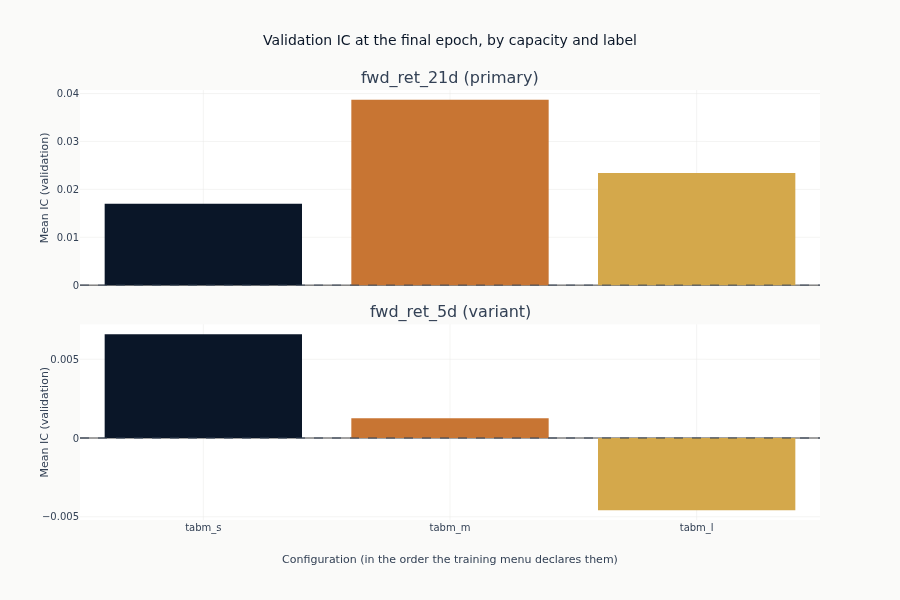

In [12]:
final = (
    catalog.filter(pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("label"))
    .filter("full_coverage")
    .sort("label", "config_name")
)

fig_capacity = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.09,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = final.filter(pl.col("label") == label)
    fig_capacity.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[color_of[name] for name in panel.get_column("config_name")],
        ),
        row=row,
        col=1,
    )
    fig_capacity.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_capacity.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_capacity.update_xaxes(
    categoryorder="array",
    categoryarray=config_order,
    title_text="Configuration (in the order the training menu declares them)",
    row=len(panel_labels),
    col=1,
)
fig_capacity.update_layout(
    title="Validation IC at the final epoch, by capacity and label",
    height=300 * len(panel_labels),
    width=900,
    showlegend=False,
    margin=dict(t=90),
)
capacity_text = ". ".join(
    "The {} panel runs from {:+.3f} to {:+.3f} with {} of {} bars above zero".format(
        label,
        final.filter(pl.col("label") == label).get_column("ic_mean").min(),
        final.filter(pl.col("label") == label).get_column("ic_mean").max(),
        final.filter((pl.col("label") == label) & (pl.col("ic_mean") > 0)).height,
        final.filter(pl.col("label") == label).height,
    )
    for label in panel_labels
)
show_plotly_with_alt(
    fig_capacity,
    "Bar charts of mean validation information coefficient at the final training epoch, one bar "
    "per configuration in menu order and coloured as in the previous figure. One panel per "
    f"label, each with its own vertical scale and a dashed zero line. {capacity_text}.",
)

### How far the epoch count moves a configuration

The two figures above measure two different things, and this frame puts them on one scale.
`across_configs` is the IC range over the three configurations at the final epoch, which is what
the capacity chart shows. `median_within_config` is the median range a single configuration
covers over its own eight checkpoints, which is what the curves show. When the second is the
larger, the stopping point moves the ranking measure further than the architecture does, and
reporting each configuration's own best checkpoint would be reporting the maximum of eight draws
as though it were one.

In [13]:
spread = (
    curves.group_by("label", "config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").sort_by("checkpoint_value").last(),
        peak_checkpoint=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort(["label", "config_name"])
)
epoch_against_capacity = (
    spread.group_by("label")
    .agg(
        configurations=pl.len(),
        across_configs=pl.col("ic_final").max() - pl.col("ic_final").min(),
        median_within_config=pl.col("checkpoint_range").median(),
    )
    .with_columns(checkpoint_dominates=pl.col("median_within_config") > pl.col("across_configs"))
    .sort("label")
)
epoch_against_capacity

label,configurations,across_configs,median_within_config,checkpoint_dominates
str,u32,f64,f64,bool
"""fwd_ret_21d""",3,0.021694,0.009337,false
"""fwd_ret_5d""",3,0.011181,0.007524,false


One row per configuration behind that comparison: the lowest and highest IC it reached across its
own checkpoints, where its highest fell, and where it finished. A peak at the first or last
checkpoint is at the edge of the schedule, which is a different situation from a peak in the
middle - it says the useful training length may lie outside the range that was searched.

In [14]:
spread

label,config_name,ic_min,ic_max,ic_final,peak_checkpoint,checkpoint_range
str,str,f64,f64,f64,i64,f64
"""fwd_ret_21d""","""tabm_l""",0.018797,0.026469,0.023395,100,0.007673
"""fwd_ret_21d""","""tabm_m""",0.027758,0.04485,0.038702,75,0.017092
"""fwd_ret_21d""","""tabm_s""",0.017009,0.026345,0.017009,50,0.009337
"""fwd_ret_5d""","""tabm_l""",-0.006447,-0.001424,-0.004585,50,0.005023
"""fwd_ret_5d""","""tabm_m""",0.000568,0.013478,0.001252,25,0.01291
"""fwd_ret_5d""","""tabm_s""",0.006596,0.01412,0.006596,25,0.007524


## 5. What to notice

**An epoch checkpoint is part of the configuration, not a detail of how it was fitted.** Three
declared configurations at eight checkpoints each are 24 candidate models per label, and the
`epoch_against_capacity` frame is how you tell whether that distinction is doing work: compare
the spread a single configuration covers over its own training run against the spread across the
configurations at a fixed training length. Where the first is comparable to the second, a
stopping point chosen after seeing the curves would be doing about as much of the ranking as the
choice of architecture. That is why every checkpoint is registered as its own prediction set
rather than each configuration reporting its own best one.

**Read the ranking with the coverage column or it will mislead you.** A network that has settled
into predicting nearly the same value for every fund contributes no rank correlation on those
dates, and its IC is then an average over the dates where it stayed non-degenerate. `ic_n_days`
is what makes that visible, and it is the same failure mode the most aggressive L1 settings
produced in [`06_linear`](06_linear.ipynb) by a different mechanism. A metric averaged over a set
the model itself selected is not a metric.

**Capacity is not a dial you turn up.** The grid steps width and ensemble size together across a
factor of four, on a cross-section of fewer than a hundred funds and a few hundred features. A
larger network has more ways to describe the training window exactly, and on a panel this small
there is not much more structure for it to find, so the useful thing to read from the capacity
chart is whether the ranking measure moves at all rather than which end wins. On a wider panel -
thousands of names rather than dozens - the same grid usually behaves differently, and that is
the comparison to make on your own data before spending a sweep on the largest configuration.

**The ensemble is what makes this cheap enough to sweep.** Averaging *k* independently trained
networks costs *k* training runs. Sharing the backbone and giving each member only its own
scaling vector and output layer costs close to one, and the parameter count grows with
`n_members` far more slowly than a separate network per member would. That is a design choice
worth recognising in other architectures: where an ensemble helps because it averages away
initialization noise rather than because its members are genuinely different models, most of the
benefit is still there once the bulk of the parameters are shared.

**None of this selects anything.** IC measures whether predictions order the cross-section
correctly, not whether a strategy trading them makes money after costs and turnover. Those are
different questions and a configuration can win the first while losing the second. Selection is
on validation backtest Sharpe over the population this notebook just published, and it happens in
[`14_backtest`](14_backtest.ipynb), where the checkpoint is part of what is selected.

**Known limitations.** The IC is an average of daily rank correlations with no adjustment for the
serial dependence that overlapping 21-day returns create, so it is a ranking diagnostic rather
than a test, and it carries no interval that would say whether these configurations differ from
each other or from the linear and boosted ones. The grid moves width and ensemble size together
at a fixed dropout, learning rate and batch size, so it cannot attribute a difference to either
dial alone. The checkpoint schedule searches training lengths in steps of 25 epochs up to 200,
and says nothing about what happens outside that range. And every number here is measured on the
validation folds, which have been read many times over by the time a case study reaches this
notebook.

**Next**: [`09_dl_lstm`](09_dl_lstm.ipynb) stops treating each decision date as an independent
row and feeds the network the recent history of each fund as a sequence, which is the one thing
none of the three families so far can see.